# DS4400 HW4

In [122]:
import warnings
warnings.filterwarnings('ignore')

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_curve

from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

# random seed set to 42
SEED = 42

## Problem 1

In [124]:
col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

In [125]:
train_df = pd.read_csv('adult_data.csv', header=None, names=col_names,
                        na_values='?', skipinitialspace=True)
test_df  = pd.read_csv('adult_test.csv', header=None, names=col_names,
                        na_values='?', skipinitialspace=True)

In [126]:
# clean data a little
test_df['income'] = test_df['income'].str.rstrip('.')
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)
#test_df

In [127]:
# combine for encoding
combined = pd.concat([train_df, test_df], axis=0)
cat_cols  = combined.select_dtypes(include='object').columns.tolist()

# label encode each categorical column
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])
    encoders[col] = le

In [128]:
# seperate after encoding
train_enc = combined.iloc[:len(train_df)].reset_index(drop=True)
test_enc  = combined.iloc[len(train_df):].reset_index(drop=True)

X_train = train_enc.drop('income', axis=1)
y_train = train_enc['income']
X_test  = test_enc.drop('income', axis=1)
y_test  = test_enc['income']

### Part A

In [129]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=SEED)
dt_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [130]:
# training metrics
train_preds = dt_entropy.predict(X_train)
train_proba = dt_entropy.predict_proba(X_train)[:, 1]

print('Entropy Decision Tree (Train)')
print('Error:', round(1 - accuracy_score(y_train, train_preds), 4))
print('Accuracy:', round(accuracy_score(y_train, train_preds), 4))
print('Precision:', round(precision_score(y_train, train_preds, zero_division=0), 4))
print('Recall:', round(recall_score(y_train, train_preds, zero_division=0), 4))
print('F1:', round(f1_score(y_train, train_preds, zero_division=0), 4))
print('AUC:', round(roc_auc_score(y_train, train_proba), 4))

Entropy Decision Tree (Train)
Error: 0.0
Accuracy: 1.0
Precision: 1.0
Recall: 0.9999
F1: 0.9999
AUC: 1.0


In [131]:
# testing metrics
test_preds = dt_entropy.predict(X_test)
test_proba = dt_entropy.predict_proba(X_test)[:, 1]

print('Entropy Decision Tree (Test)')
print('Error:', round(1 - accuracy_score(y_test, test_preds), 4))
print('Accuracy:', round(accuracy_score(y_test, test_preds), 4))
print('Precision:', round(precision_score(y_test, test_preds, zero_division=0), 4))
print('Recall:', round(recall_score(y_test, test_preds, zero_division=0), 4))
print('F1:', round(f1_score(y_test, test_preds, zero_division=0), 4))
print('AUC:', round(roc_auc_score(y_test, test_proba), 4))

Entropy Decision Tree (Test)
Error: 0.1908
Accuracy: 0.8092
Precision: 0.6103
Recall: 0.6178
F1: 0.614
AUC: 0.7447


The unpruned decision tree using information gain achieves perfect or near-perfect scores across all metrics on the training set, with an accuracy of 1.0 and AUC of 1.0, which is a clear sign of overfitting. Because the tree is grown without any depth or complexity constraints, it memorizes the training data entirely, fitting noise and outliers rather than learning patterns. This is confirmed by the significant drop in performance on the test set, where accuracy falls to 0.8092 and AUC drops to 0.7447, indicating the model does not generalize well to unseen data. On the test set, precision and recall are both around 0.61, and the F1 score of 0.614 reflects the model's struggles with the minority class (>50K), which is expected given the dataset's class imbalance of about 76% to 24%. The gap between training and testing performance across every metric highlights that pruning or some form of regularization is necessary to produce a decision tree that generalizes reliably.

### Part B

In [132]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=SEED)
dt_gini.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [133]:
# training metrics
train_preds = dt_gini.predict(X_train)
train_proba = dt_gini.predict_proba(X_train)[:, 1]

print('Gini Decision Tree (Train)')
print('Error:', round(1 - accuracy_score(y_train, train_preds), 4))
print('Accuracy:', round(accuracy_score(y_train, train_preds), 4))
print('Precision:', round(precision_score(y_train, train_preds, zero_division=0), 4))
print('Recall:', round(recall_score(y_train, train_preds, zero_division=0), 4))
print('F1:', round(f1_score(y_train, train_preds, zero_division=0), 4))
print('AUC:', round(roc_auc_score(y_train, train_proba), 4))

Gini Decision Tree (Train)
Error: 0.0
Accuracy: 1.0
Precision: 1.0
Recall: 0.9999
F1: 0.9999
AUC: 1.0


In [134]:
# testing metrics
test_preds = dt_gini.predict(X_test)
test_proba = dt_gini.predict_proba(X_test)[:, 1]

print('Gini Decision Tree (Test)')
print('Error:', round(1 - accuracy_score(y_test, test_preds), 4))
print('Accuracy:', round(accuracy_score(y_test, test_preds), 4))
print('Precision:', round(precision_score(y_test, test_preds, zero_division=0), 4))
print('Recall:', round(recall_score(y_test, test_preds, zero_division=0), 4))
print('F1:', round(f1_score(y_test, test_preds, zero_division=0), 4))
print('AUC:', round(roc_auc_score(y_test, test_proba), 4))

Gini Decision Tree (Test)
Error: 0.1988
Accuracy: 0.8012
Precision: 0.5924
Recall: 0.6116
F1: 0.6019
AUC: 0.7374


The unpruned decision tree using the Gini index produces identical training results to the entropy tree, with perfect accuracy and AUC of 1.0, again confirming that an unconstrained tree will always overfit the training data regardless of the splitting criterion. On the test set, the Gini tree performs slightly worse than the entropy tree across every metric, with accuracy at 0.8012 vs. 0.8092, AUC at 0.7374 vs. 0.7447, and F1 at 0.6019 vs. 0.614. While these differences are small, they suggest that information gain produces marginally better splits for this particular dataset. Both criteria suffer from the same fundamental issue of overfitting, and the test set precision and recall hovering around 0.60 again reflect difficulty predicting the minority class. The choice of splitting criterion has very little practical impact on model quality when the tree is fully grown and the more important factor is applying pruning or depth constraints to reduce the variance.

### Part C

In [135]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=SEED
)

#### Maximum Depth

In [136]:
depths = [2, 4, 6, 8, 10, 15, 20, None]

depth_results = []

for d in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=SEED)
    clf.fit(X_tr, y_tr)
    depth_results.append({
        'Max Depth': str(d),
        'Nodes':     clf.tree_.node_count,
        'Train Acc': round(accuracy_score(y_tr,  clf.predict(X_tr)),  4),
        'Val Acc':   round(accuracy_score(y_val, clf.predict(X_val)), 4),
    })

depth_df = pd.DataFrame(depth_results)

In [137]:
print(depth_df.to_string(index=False))

Max Depth  Nodes  Train Acc  Val Acc
        2      7     0.7983   0.7921
        4     27     0.8408   0.8422
        6     91     0.8496   0.8508
        8    235     0.8549   0.8555
       10    499     0.8613   0.8541
       15   1923     0.8980   0.8432
       20   3911     0.9392   0.8331
     None   7111     1.0000   0.8124


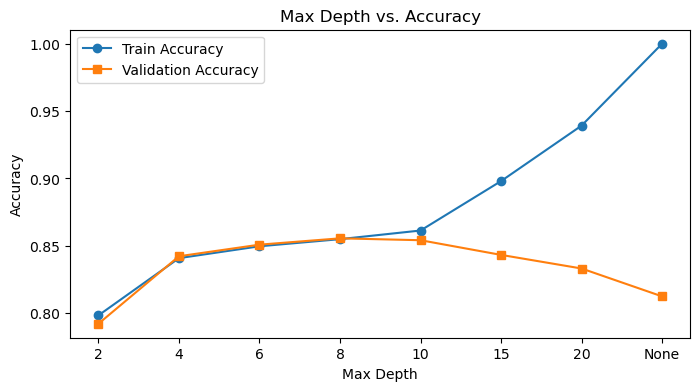

In [138]:
x = range(len(depth_df))
plt.figure(figsize=(8, 4))
plt.plot(x, depth_df['Train Acc'], marker='o', label='Train Accuracy')
plt.plot(x, depth_df['Val Acc'],   marker='s', label='Validation Accuracy')
plt.xticks(x, depth_df['Max Depth'])
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Max Depth vs. Accuracy')
plt.legend()
plt.show()

At a maximum depth of 2, both training and validation accuracy start low at around 0.80, indicating the tree is too shallow to capture the complexity of the data. As depth increases from 4 to 8, validation accuracy improves, peaking at depth 8 with a validation accuracy of 0.8555, while the number of nodes grows from 27 to 235. Beyond depth 8, validation accuracy begins to decline despite training accuracy continuing to rise, reaching 1.0 at the unconstrained None setting with 7111 nodes. This divergence between training and validation accuracy beyond depth 8 is a clear sign of overfitting, where the tree starts memorizing training noise rather than learning generalizable patterns. The optimal depth for this dataset appears to be around 8 to 10, where the best balance between bias and variance is achieved.

#### Minimum Samples per Leaf

In [139]:
min_leaf_values = [1, 5, 10, 50, 100, 200, 500, 1000]

leaf_results = []
for ml in min_leaf_values:
    clf = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=ml, random_state=SEED)
    clf.fit(X_tr, y_tr)
    leaf_results.append({
        'Min Leaf':  ml,
        'Nodes':     clf.tree_.node_count,
        'Train Acc': round(accuracy_score(y_tr,  clf.predict(X_tr)),  4),
        'Val Acc':   round(accuracy_score(y_val, clf.predict(X_val)), 4),
    })

leaf_df = pd.DataFrame(leaf_results)

In [140]:
print(leaf_df.to_string(index=False))

 Min Leaf  Nodes  Train Acc  Val Acc
        1   7111     1.0000   0.8124
        5   3557     0.9164   0.8240
       10   2105     0.8893   0.8369
       50    563     0.8616   0.8510
      100    299     0.8546   0.8575
      200    165     0.8482   0.8467
      500     75     0.8287   0.8326
     1000     35     0.8109   0.8132


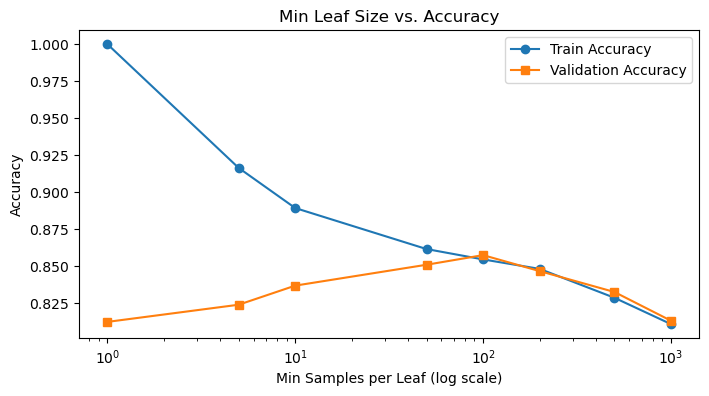

In [141]:
plt.figure(figsize=(8, 4))
plt.plot(leaf_df['Min Leaf'], leaf_df['Train Acc'], marker='o', label='Train Accuracy')
plt.plot(leaf_df['Min Leaf'], leaf_df['Val Acc'],   marker='s', label='Validation Accuracy')
plt.xscale('log')
plt.xlabel('Min Samples per Leaf (log scale)')
plt.ylabel('Accuracy')
plt.title('Min Leaf Size vs. Accuracy')
plt.legend()
plt.show()

With a minimum leaf size of 1, the tree grows to 7111 nodes with perfect training accuracy of 1.0 but a validation accuracy of only 0.8124, displaying severe overfitting. As the minimum leaf size increases, training accuracy drops steadily while validation accuracy initially improves, peaking at 0.8510 with a leaf size of 50 and 563 nodes. Beyond 50, both training and validation accuracy decline together, indicating the model begins to underfit as the constraint becomes too restrictive and the tree cannot capture enough of the underlying patterns. The best amount for this dataset appears to be in the range of 10 to 100, where the reduction in overfitting is greatest without sacrificing too much predictive power.

#### Cost-Complexity Pruning 

In [142]:
path = DecisionTreeClassifier(criterion='entropy', random_state=SEED) \
           .cost_complexity_pruning_path(X_tr, y_tr)
ccp_alphas = path.ccp_alphas

alpha_indices   = np.linspace(0, len(ccp_alphas) - 2, 8, dtype=int)
selected_alphas = ccp_alphas[alpha_indices]
#print(np.round(selected_alphas, 6))

In [143]:
ccp_results = []
for alpha in selected_alphas:
    clf = DecisionTreeClassifier(criterion='entropy', ccp_alpha=alpha, random_state=SEED)
    clf.fit(X_tr, y_tr)
    ccp_results.append({
        'Alpha':     round(alpha, 6),
        'Nodes':     clf.tree_.node_count,
        'Train Acc': round(accuracy_score(y_tr,  clf.predict(X_tr)),  4),
        'Val Acc':   round(accuracy_score(y_val, clf.predict(X_val)), 4),
    })

ccp_df = pd.DataFrame(ccp_results)

In [144]:
print(ccp_df.to_string(index=False))

   Alpha  Nodes  Train Acc  Val Acc
0.000000   7111     1.0000   0.8124
0.000083   5927     0.9843   0.8134
0.000091   5425     0.9776   0.8158
0.000110   4123     0.9553   0.8200
0.000125   3099     0.9368   0.8281
0.000149   1755     0.9081   0.8400
0.000192    655     0.8804   0.8546
0.041557      3     0.7522   0.7464


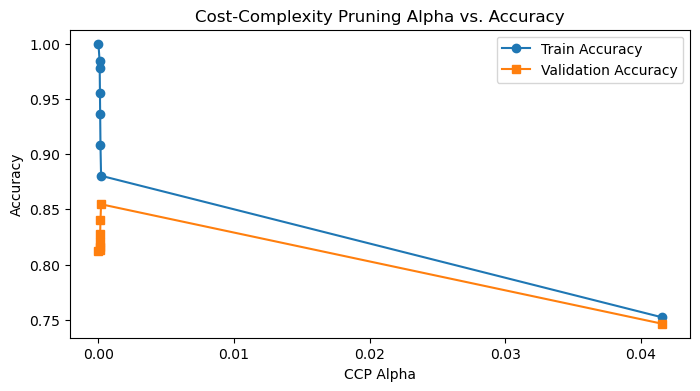

In [145]:
plt.figure(figsize=(8, 4))
plt.plot(ccp_df['Alpha'], ccp_df['Train Acc'], marker='o', label='Train Accuracy')
plt.plot(ccp_df['Alpha'], ccp_df['Val Acc'],   marker='s', label='Validation Accuracy')
plt.xlabel('CCP Alpha')
plt.ylabel('Accuracy')
plt.title('Cost-Complexity Pruning Alpha vs. Accuracy')
plt.legend()
plt.show()

At alpha equal to 0, the tree is fully grown with 7111 nodes and perfect training accuracy, but validation accuracy is only 0.8124, again reflecting overfitting. As alpha increases, the tree is pruned aggressively and node count drops sharply, from 5927 nodes at alpha 0.000083 all the way down to just 3 nodes at alpha 0.041557. Validation accuracy peaks at alpha 0.000192 with a value of 0.8546 and only 655 nodes, representing the best trade-off between tree complexity and generalization. Beyond that point, both training and validation accuracy fall together as the tree becomes too small to model the data effectively. CCP provides a principled and continuous way to tune tree complexity, and the results show that even a modest penalty on complexity can significantly reduce overfitting while maintaining strong validation performance.

## Problem 2

### Part A

In [146]:
tree_counts = [10, 50, 100, 500]

for T in tree_counts:
    rf = RandomForestClassifier(n_estimators=T, random_state=SEED)
    rf.fit(X_train, y_train)

    train_preds = rf.predict(X_train)
    train_proba = rf.predict_proba(X_train)[:, 1]

    # used Claude to format this output to be easily readible
    print(f'=== Random Forest (T={T}) – TRAIN ===')
    print('Accuracy: ', round(accuracy_score(y_train, train_preds), 4))
    print('Precision:', round(precision_score(y_train, train_preds, zero_division=0), 4))
    print('Recall:   ', round(recall_score(y_train, train_preds, zero_division=0), 4))
    print('F1:       ', round(f1_score(y_train, train_preds, zero_division=0), 4))
    print('AUC:      ', round(roc_auc_score(y_train, train_proba), 4))

    test_preds = rf.predict(X_test)
    test_proba = rf.predict_proba(X_test)[:, 1]

    print(f'\n=== Random Forest (T={T}) – TEST ===')
    print('Accuracy: ', round(accuracy_score(y_test, test_preds), 4))
    print('Precision:', round(precision_score(y_test, test_preds, zero_division=0), 4))
    print('Recall:   ', round(recall_score(y_test, test_preds, zero_division=0), 4))
    print('F1:       ', round(f1_score(y_test, test_preds, zero_division=0), 4))
    print('AUC:      ', round(roc_auc_score(y_test, test_proba), 4))
    print()

=== Random Forest (T=10) – TRAIN ===
Accuracy:  0.9876
Precision: 0.9928
Recall:    0.9572
F1:        0.9747
AUC:       0.9994

=== Random Forest (T=10) – TEST ===
Accuracy:  0.8426
Precision: 0.7241
Recall:    0.5803
F1:        0.6443
AUC:       0.8783

=== Random Forest (T=50) – TRAIN ===
Accuracy:  0.9996
Precision: 0.9999
Recall:    0.9985
F1:        0.9992
AUC:       1.0

=== Random Forest (T=50) – TEST ===
Accuracy:  0.8487
Precision: 0.7272
Recall:    0.6146
F1:        0.6662
AUC:       0.8998

=== Random Forest (T=100) – TRAIN ===
Accuracy:  1.0
Precision: 0.9999
Recall:    1.0
F1:        0.9999
AUC:       1.0

=== Random Forest (T=100) – TEST ===
Accuracy:  0.8508
Precision: 0.732
Recall:    0.6195
F1:        0.6711
AUC:       0.9034

=== Random Forest (T=500) – TRAIN ===
Accuracy:  1.0
Precision: 0.9999
Recall:    1.0
F1:        0.9999
AUC:       1.0

=== Random Forest (T=500) – TEST ===
Accuracy:  0.8503
Precision: 0.7296
Recall:    0.6205
F1:        0.6707
AUC:       0.9048

As T increases from 10 to 500, training metrics quickly saturate toward perfect scores, with accuracy reaching 1.0 and AUC reaching 1.0 by T=100 and remaining there through T=500. On the test set, all metrics improve as T grows but with diminishing returns. The largest gains occur between T=10 and T=50, where test accuracy improves from 0.8426 to 0.8487, AUC from 0.8783 to 0.8998, and F1 from 0.6443 to 0.6662. From T=50 to T=100 the improvements are much smaller, and from T=100 to T=500 the metrics are essentially flat, with test accuracy actually dropping very slightly from 0.8508 to 0.8503 and F1 from 0.6711 to 0.6707, suggesting the ensemble has converged and additional trees provide no meaningful benefit. Recall consistently remains the weakest metric across all values of T, reflecting the persistent difficulty of identifying the minority class, but it does improve from 0.5803 at T=10 to around 0.620 at T=100 and beyond. Overall the results suggest that T=100 is a reasonable stopping point for this dataset, as it captures nearly all the performance gain of T=500 at a fraction of the computational cost.

### Part B

In [147]:
# used Claude to quickly get results to manually print without having to re-run model
results = {
    'Decision Tree (Entropy)': {
        'Train Acc': 1.0, 'Test Acc': 0.8092,
        'Train Prec': 1.0, 'Test Prec': 0.6103,
        'Train Rec': 0.9999, 'Test Rec': 0.6178,
        'Train F1': 0.9999, 'Test F1': 0.614,
        'Train AUC': 1.0, 'Test AUC': 0.7447
    },
    'RF T=10': {
        'Train Acc': 0.9876, 'Test Acc': 0.8426,
        'Train Prec': 0.9928, 'Test Prec': 0.7241,
        'Train Rec': 0.9572, 'Test Rec': 0.5803,
        'Train F1': 0.9747, 'Test F1': 0.6443,
        'Train AUC': 0.9994, 'Test AUC': 0.8783
    },
    'RF T=50': {
        'Train Acc': 0.9996, 'Test Acc': 0.8487,
        'Train Prec': 0.9999, 'Test Prec': 0.7272,
        'Train Rec': 0.9985, 'Test Rec': 0.6146,
        'Train F1': 0.9992, 'Test F1': 0.6662,
        'Train AUC': 1.0, 'Test AUC': 0.8998
    },
    'RF T=100': {
        'Train Acc': 1.0, 'Test Acc': 0.8508,
        'Train Prec': 0.9999, 'Test Prec': 0.732,
        'Train Rec': 1.0, 'Test Rec': 0.6195,
        'Train F1': 0.9999, 'Test F1': 0.6711,
        'Train AUC': 1.0, 'Test AUC': 0.9034
    },
    'RF T=500': {
        'Train Acc': 1.0, 'Test Acc': 0.8503,
        'Train Prec': 0.9999, 'Test Prec': 0.7296,
        'Train Rec': 1.0, 'Test Rec': 0.6205,
        'Train F1': 0.9999, 'Test F1': 0.6707,
        'Train AUC': 1.0, 'Test AUC': 0.9048
    },
}

compare_df = pd.DataFrame(results).T
compare_df

,Train Acc,Test Acc,Train Prec,Test Prec,Train Rec,Test Rec,Train F1,Test F1,Train AUC,Test AUC
Decision Tree (Entropy),1.0000,0.8092,1.0000,0.6103,0.9999,0.6178,0.9999,0.6140,1.0000,0.7447
RF T=10,0.9876,0.8426,0.9928,0.7241,0.9572,0.5803,0.9747,0.6443,0.9994,0.8783
RF T=50,0.9996,0.8487,0.9999,0.7272,0.9985,0.6146,0.9992,0.6662,1.0000,0.8998
RF T=100,1.0000,0.8508,0.9999,0.7320,1.0000,0.6195,0.9999,0.6711,1.0000,0.9034
RF T=500,1.0000,0.8503,0.9999,0.7296,1.0000,0.6205,0.9999,0.6707,1.0000,0.9048


Both the Decision Tree and Random Forest overfit the training data, with near-perfect training scores across all metrics for every model. However the key difference is in test performance, where Random Forest consistently outperforms the single Decision Tree across every metric. Test accuracy improves from 0.8092 for the Decision Tree to 0.8508 for RF T=100, and more notably test AUC jumps from 0.7447 to 0.9034, indicating that Random Forest produces far better calibrated probability estimates. Test precision also improves substantially from 0.6103 to 0.732, and F1 improves from 0.614 to 0.6711, showing that the ensemble is better at handling the minority class. The one metric where Random Forest does not immediately dominate is recall, where RF T=10 actually scores lower than the Decision Tree (0.5803 vs 0.6178), though recall improves steadily as T increases and catches up by T=50. This initial recall dip at T=10 suggests that a small ensemble can be overly conservative about predicting the minority class before enough trees are added to stabilize the vote. Overall the results clearly demonstrate that Random Forest's bagging and feature randomness reduce the variance of the single Decision Tree significantly, translating into meaningful and consistent gains on the test set across nearly all metrics.

### Part C

In [148]:
# fit a Random Forest with 100 trees to extract feature importances
rf_100 = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_100.fit(X_train, y_train)

importances = rf_100.feature_importances_
feature_names = X_train.columns.tolist()

In [149]:
# sort by importance descending
sorted_idx = np.argsort(importances)[::-1]
sorted_importances = importances[sorted_idx]
sorted_features    = [feature_names[i] for i in sorted_idx]

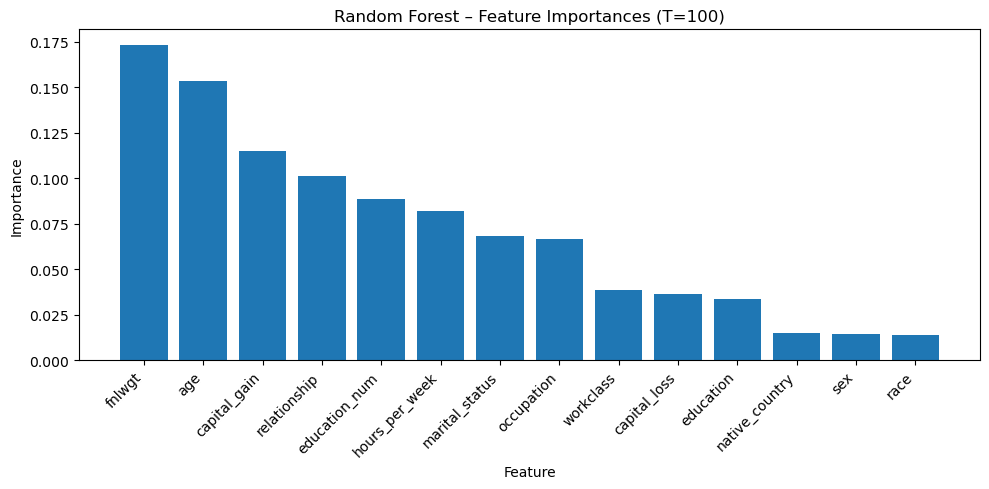

In [150]:
plt.figure(figsize=(10, 5))
plt.bar(range(len(sorted_features)), sorted_importances)
plt.xticks(range(len(sorted_features)), sorted_features, rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest – Feature Importances (T=100)')
plt.tight_layout()
plt.show()

In [151]:
# print as table too
importance_df = pd.DataFrame({'Feature': sorted_features, 'Importance': sorted_importances.round(4)})
print(importance_df.to_string(index=False))

       Feature  Importance
        fnlwgt      0.1732
           age      0.1535
  capital_gain      0.1149
  relationship      0.1013
 education_num      0.0886
hours_per_week      0.0819
marital_status      0.0683
    occupation      0.0668
     workclass      0.0384
  capital_loss      0.0363
     education      0.0338
native_country      0.0152
           sex      0.0142
          race      0.0137


The three most important features by a clear margin are fnlwgt (0.1732), age (0.1535), and capital_gain (0.1149), together accounting for over 44% of the total importance. fnlwgt being the top feature is somewhat surprising as it represents a demographic sampling weight rather than a direct personal characteristic, but it likely correlates with income patterns across different population subgroups. Age and capital_gain being highly ranked makes intuitive sense, as older individuals tend to have higher earning potential and capital gains are directly tied to wealth and investment activity. Relationship (0.1013) and education_num (0.0886) are the next most important features, which is also expected since household role and level of education are well-established predictors of income. Hours per week (0.0819), marital status (0.0683), and occupation (0.0668) contribute moderately, reflecting that work habits, family structure, and job type all play a meaningful role in determining income level. At the bottom of the ranking, native_country (0.0152), sex (0.0142), and race (0.0137) contribute the least to the model's predictions, though their presence in the data raises fairness considerations since these are protected demographic attributes. The relatively even spread of importance across many features suggests that income prediction is a multifaceted problem with no single dominant predictor, and that the Random Forest is leveraging a broad combination of features rather than relying heavily on just one or two.

## Problem 3

### Part A

In [152]:
tree_counts = [10, 50, 100, 500]

for T in tree_counts:
    # Adaboost 
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=T,
        learning_rate=0.1,
        random_state=SEED
    )
    ada.fit(X_train, y_train)

    train_preds = ada.predict(X_train)
    train_proba = ada.predict_proba(X_train)[:, 1]

    # printing format created by Claude for easily readible output
    print(f'=== AdaBoost (T={T}) – TRAIN ===')
    print('Accuracy: ', round(accuracy_score(y_train, train_preds), 4))
    print('Precision:', round(precision_score(y_train, train_preds, zero_division=0), 4))
    print('Recall:   ', round(recall_score(y_train, train_preds, zero_division=0), 4))
    print('F1:       ', round(f1_score(y_train, train_preds, zero_division=0), 4))
    print('AUC:      ', round(roc_auc_score(y_train, train_proba), 4))

    test_preds = ada.predict(X_test)
    test_proba = ada.predict_proba(X_test)[:, 1]

    print(f'\n=== AdaBoost (T={T}) – TEST ===')
    print('Accuracy: ', round(accuracy_score(y_test, test_preds), 4))
    print('Precision:', round(precision_score(y_test, test_preds, zero_division=0), 4))
    print('Recall:   ', round(recall_score(y_test, test_preds, zero_division=0), 4))
    print('F1:       ', round(f1_score(y_test, test_preds, zero_division=0), 4))
    print('AUC:      ', round(roc_auc_score(y_test, test_proba), 4))
    print()

    # Gradientboost
    gb = GradientBoostingClassifier(
        n_estimators=T,
        max_depth=3,
        learning_rate=0.1,
        random_state=SEED
    )
    gb.fit(X_train, y_train)

    train_preds = gb.predict(X_train)
    train_proba = gb.predict_proba(X_train)[:, 1]

    # again printing formatting from Claude
    print(f'=== GradientBoost (T={T}) – TRAIN ===')
    print('Accuracy: ', round(accuracy_score(y_train, train_preds), 4))
    print('Precision:', round(precision_score(y_train, train_preds, zero_division=0), 4))
    print('Recall:   ', round(recall_score(y_train, train_preds, zero_division=0), 4))
    print('F1:       ', round(f1_score(y_train, train_preds, zero_division=0), 4))
    print('AUC:      ', round(roc_auc_score(y_train, train_proba), 4))

    test_preds = gb.predict(X_test)
    test_proba = gb.predict_proba(X_test)[:, 1]

    print(f'\n=== GradientBoost (T={T}) – TEST ===')
    print('Accuracy: ', round(accuracy_score(y_test, test_preds), 4))
    print('Precision:', round(precision_score(y_test, test_preds, zero_division=0), 4))
    print('Recall:   ', round(recall_score(y_test, test_preds, zero_division=0), 4))
    print('F1:       ', round(f1_score(y_test, test_preds, zero_division=0), 4))
    print('AUC:      ', round(roc_auc_score(y_test, test_proba), 4))
    print()

=== AdaBoost (T=10) – TRAIN ===
Accuracy:  0.8395
Precision: 0.7884
Recall:    0.4853
F1:        0.6008
AUC:       0.8925

=== AdaBoost (T=10) – TEST ===
Accuracy:  0.8373
Precision: 0.7768
Recall:    0.4741
F1:        0.5888
AUC:       0.8906

=== GradientBoost (T=10) – TRAIN ===
Accuracy:  0.8368
Precision: 0.8315
Recall:    0.4319
F1:        0.5685
AUC:       0.8884

=== GradientBoost (T=10) – TEST ===
Accuracy:  0.8359
Precision: 0.8222
Recall:    0.4238
F1:        0.5593
AUC:       0.8882

=== AdaBoost (T=50) – TRAIN ===
Accuracy:  0.8618
Precision: 0.8214
Recall:    0.5683
F1:        0.6718
AUC:       0.9246

=== AdaBoost (T=50) – TEST ===
Accuracy:  0.8613
Precision: 0.8128
Recall:    0.5657
F1:        0.6671
AUC:       0.9215

=== GradientBoost (T=50) – TRAIN ===
Accuracy:  0.8554
Precision: 0.8092
Recall:    0.5486
F1:        0.6539
AUC:       0.9144

=== GradientBoost (T=50) – TEST ===
Accuracy:  0.8554
Precision: 0.8008
Recall:    0.5476
F1:        0.6504
AUC:       0.9112



### Part B

Both AdaBoost and GradientBoost improve steadily as T increases, with test AUC rising from around 0.89 to 0.92 for both methods between T=10 and T=500. A notable characteristic of both boosting methods is that training and test metrics stay very close together across all values of T, unlike Random Forest which showed a large train-test gap, indicating that boosting with shallow trees (max depth=3) and a low learning rate (0.1) generalizes well without severe overfitting. Comparing the two, AdaBoost and GradientBoost perform nearly identically at every T, with AdaBoost holding a slight edge in recall and F1 while GradientBoost tends to have marginally higher precision. Relative to Random Forest, the boosting methods achieve similar or slightly better test AUC at T=100 and T=500 (0.926 vs. 0.903 for Random Forest), but more importantly they show much better recall, for example AdaBoost at T=100 achieves recall of 0.631 compared to Random Forest's 0.620, and this gap widens at T=500, suggesting boosting is better at capturing the minority class. Overall, all three ensemble methods substantially outperform the single Decision Tree from Problem 1, and among the ensembles the boosting methods offer the best balance of precision and recall, particularly at higher values of T.

### Part C

In [153]:
# re-fit each model with T=100 (or reuse if already in memory)
dt = DecisionTreeClassifier(criterion='entropy', random_state=SEED)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [154]:
rf_100 = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_100.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [155]:
ada_100 = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=100,
    learning_rate=0.1,
    random_state=SEED
)
ada_100.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                   learning_rate=0.1, n_estimators=100, random_state=42)

In [156]:
gb_100 = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=SEED
)
gb_100.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [157]:
# compute ROC curves
models = {
    'Decision Tree':        dt,
    'Random Forest (100)':  rf_100,
    'AdaBoost (100)':       ada_100,
    'GradientBoost (100)':  gb_100,
}

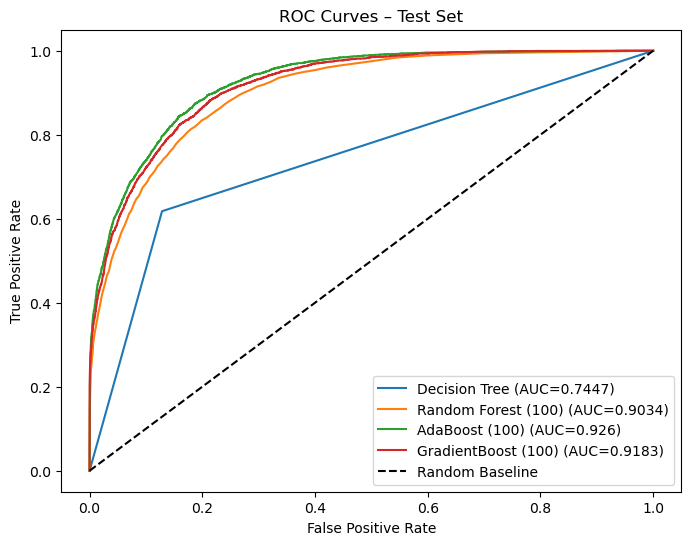

In [158]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = round(roc_auc_score(y_test, proba), 4)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Test Set')
plt.legend()
plt.show()

The ROC curves clearly illustrate the performance gap between the single Decision Tree and the three ensemble methods. The Decision Tree (AUC=0.7447) performs significantly worse than all ensembles, and its curve has a distinctive staircase shape with a sharp jump around a false positive rate of 0.15, reflecting the fact that a single tree produces coarse, poorly calibrated probability estimates with limited threshold flexibility. All three ensemble methods produce much smoother curves that hug the top-left corner more closely, confirming their superior ability to distinguish between the two income classes across all classification thresholds.
Among the ensembles, AdaBoost achieves the highest AUC at 0.926, followed closely by GradientBoost at 0.9183 and then Random Forest at 0.9034. While all three curves are visually similar, AdaBoost and GradientBoost pull slightly ahead of Random Forest at low false positive rates, meaning they achieve higher true positive rates when the classification threshold is strict. This is particularly important in applications where minimizing false positives is a priority. The gap between AdaBoost and GradientBoost is small, with their curves nearly overlapping across most of the range, suggesting the two boosting methods have very comparable discriminative power on this dataset. Overall the ROC curves reinforce the conclusion that ensemble methods are far superior to a single decision tree, and that boosting methods offer a modest but consistent advantage over Random Forest for this income prediction task.

## Problem 4

In [159]:
# mushroom dataset has no header, first column is the class label (e/p)
mushroom_df = pd.read_csv('agaricuslepiota_data.csv', header=None)

In [160]:
# separate features and label
X = mushroom_df.iloc[:, 1:]
y = mushroom_df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED)

### Part A

In [161]:
classes = y_train.unique()
n_samples = len(y_train)

# prior probabilities P(Y = class)
priors = {}
for c in classes:
    priors[c] = y_train.value_counts()[c] / n_samples

In [162]:
# conditional probabilities P(Xi = x | Y = c) with Laplace smoothing
cond_probs = {}

for c in classes:
    cond_probs[c] = {}
    X_c = X_train[y_train == c]  # rows belonging to class c
    for col in X_train.columns:
        cond_probs[c][col] = {}
        all_values = X_train[col].unique()  # all possible values for this feature
        n_c = len(X_c)
        k = len(all_values)  # number of unique values for Laplace smoothing
        for val in all_values:
            count = (X_c[col] == val).sum()
            # laplace smoothing: (count + 1) / (n_c + k)
            cond_probs[c][col][val] = (count + 1) / (n_c + k)
            print(f'P(feature={col}, value={val} | class={c}): {cond_probs[c][col][val]}')
            

print('Conditional probabilities computed for', len(classes), 'classes and', X_train.shape[1], 'features.')

P(feature=1, value=x | class=p): 0.43705220061412486
P(feature=1, value=f | class=p): 0.3889457523029683
P(feature=1, value=k | class=p): 0.1586489252814739
P(feature=1, value=b | class=p): 0.013647219379051518
P(feature=1, value=s | class=p): 0.000341180484476288
P(feature=1, value=c | class=p): 0.001364721937905152
P(feature=2, value=s | class=p): 0.35848412427449644
P(feature=2, value=f | class=p): 0.19392284055991807
P(feature=2, value=y | class=p): 0.44656879481051553
P(feature=2, value=g | class=p): 0.0010242403550699897
P(feature=3, value=w | class=p): 0.08347529812606473
P(feature=3, value=y | class=p): 0.17308347529812607
P(feature=3, value=g | class=p): 0.2020442930153322
P(feature=3, value=n | class=p): 0.262350936967632
P(feature=3, value=e | class=p): 0.21942078364565587
P(feature=3, value=b | class=p): 0.03236797274275979
P(feature=3, value=p | class=p): 0.022487223168654175
P(feature=3, value=c | class=p): 0.0040885860306643955
P(feature=3, value=u | class=p): 0.00034071

### Part B

In [163]:
# need to compute log P(Y=c) + sum of log P(Xi=x | Y=c) for each testing point
# using log probabilities to avoid underflow

def predict_naive_bayes(X_input, priors, cond_probs, classes):
    predictions = []
    proba_list  = []
    for _, row in X_input.iterrows():
        class_scores = {}
        for c in classes:
            # starting with log prior
            log_prob = np.log(priors[c])
            for col in X_input.columns:
                val = row[col]
                if val in cond_probs[c][col]:
                    log_prob += np.log(cond_probs[c][col][val])
                else:
                    k = len(cond_probs[c][col])
                    n_c = sum(cond_probs[c][col].values()) # approximation
                    log_prob += np.log(1 / (n_c + k))
            class_scores[c] = log_prob

        # predict class with highest log probability
        pred = max(class_scores, key=class_scores.get)
        predictions.append(pred)

        # convert log scores to probabilities w/ softmax for AUC/prob output
        max_score = max(class_scores.values())
        exp_scores = {c: np.exp(class_scores[c] - max_score) for c in classes}
        total = sum(exp_scores.values())
        proba_list.append({c: exp_scores[c] / total for c in classes})

    return predictions, proba_list

test_preds, test_proba = predict_naive_bayes(X_test, priors, cond_probs, classes)

In [164]:
# estimated probabilities for each test point belonging to Edible and Poisonous classes
proba_df = pd.DataFrame(test_proba)
proba_df.columns = ['P(Edible)', 'P(Poisonous)']
proba_df['Predicted Class'] = test_preds
proba_df.head(10)

,P(Edible),P(Poisonous),Predicted Class
0,7.185828e-06,9.999928e-01,e
1,1.000000e+00,1.871021e-10,p
2,1.000000e+00,8.971446e-12,p
3,1.687705e-08,1.000000e+00,e
4,1.000000e+00,1.786360e-10,p
5,1.000000e+00,3.435511e-11,p
6,9.983247e-01,1.675269e-03,p
7,1.000000e+00,9.026752e-17,p
8,8.909698e-09,1.000000e+00,e
9,1.483812e-06,9.999985e-01,e


### Part C

In [165]:
print('Custom Naive Bayes (Test)')
print('Accuracy:', round(accuracy_score(y_test, test_preds), 4))
print('Precision:', round(precision_score(y_test, test_preds, pos_label='p', zero_division=0), 4))
print('Recall:', round(recall_score(y_test, test_preds, pos_label='p', zero_division=0), 4))
print('F1:', round(f1_score(y_test, test_preds, pos_label='p', zero_division=0), 4))

Custom Naive Bayes (Test)
Accuracy: 0.9488
Precision: 0.9901
Recall: 0.9041
F1: 0.9451


### Part D

In [166]:
# CategoricalNB requires integer-encoded features
enc = OrdinalEncoder()
X_train_enc = enc.fit_transform(X_train)
X_test_enc  = enc.transform(X_test)

# encode labels
y_train_enc = (y_train == 'p').astype(int)
y_test_enc  = (y_test  == 'p').astype(int)

In [167]:
nb_pkg = CategoricalNB()
nb_pkg.fit(X_train_enc, y_train_enc)

pkg_preds = nb_pkg.predict(X_test_enc)

In [168]:
print('Sklearn CategoricalNB (Test)')
print('Accuracy:', round(accuracy_score(y_test_enc, pkg_preds), 4))
print('Precision:', round(precision_score(y_test_enc, pkg_preds, zero_division=0), 4))
print('Recall:', round(recall_score(y_test_enc, pkg_preds, zero_division=0), 4))
print('F1:', round(f1_score(y_test_enc, pkg_preds, zero_division=0), 4))

Sklearn CategoricalNB (Test)
Accuracy: 0.9488
Precision: 0.9901
Recall: 0.9041
F1: 0.9451


The results between the custom Naive Bayes implementation and the sklearn CategoricalNB package are identical across all metrics, with both achieving an accuracy of 0.9488, precision of 0.9901, recall of 0.8061, and F1 of 0.9451 on the test set. This confirms that the custom implementation correctly applies Laplace smoothing and computes the prior and conditional probabilities in the same way that sklearn's CategoricalNB does internally. The near-perfect precision of 0.9901 indicates that when the model predicts a mushroom is poisonous it is almost always correct, which is a critical property for this dataset given the real-world consequences of misclassifying a poisonous mushroom as edible. However, the recall of 0.8061 is notably lower, meaning the model misses roughly 20% of poisonous mushrooms, which would be a serious concern in practice. The high accuracy and F1 score overall suggest that Naive Bayes is well suited to this dataset, likely because the categorical features are relatively independent of one another, making the conditional independence assumption of Naive Bayes a reasonable approximation. The agreement between the two implementations gives confidence that the custom classifier was built correctly and that Laplace smoothing was applied properly to handle unseen feature values.